# Pipeline for the training of the PINN model for recovering scalar field potential $V(\phi)$ associated to the first branch (FB) of the given $S(T)$ equation of state

In [1]:
import os
os.environ["DEV"] = "1"
os.environ["NEURODIFF_API_URL"] = "http://dev.neurodiff.io"
os.environ["NEURODIFF_API_KEY"] = 'tNaaIvvvdg72-c8VcTZRgpALsl0ns77ljEvxul6tG0E'

import warnings

warnings.filterwarnings("ignore")
import dill
dill.__version__

import numpy
from FB_main_pipeline import *
from tqdm.auto import tqdm


from matplotlib import cm
import matplotlib.colors as mcolors

plt.rcParams['font.family'] = 'DejaVu Serif'  # This is available by default with matplotlib
import warnings
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


In [2]:
# Path to save the results (and store/load pretrained models)

path_results = os.getcwd() + '/FB_results/'

if not os.path.exists(path_results):
    os.makedirs(path_results)

In [3]:
path_results

'/Users/pablotejerina/PhD/NNholo/False_Vacuum_paper/0_55/pretrained_SB_with_new_FB_phiFV_069_test_1/git/FB_results/'

In [4]:
# Choose the phiM parameter value of the V(phi) potential, this will be used for importing the data file for training the PINN model

phim_param=[0.55] # , 0.8]

sofT_list = []
for k in range(len(phim_param)):
    phim_str = str(phim_param[k])
    phim_str = phim_str.replace('.', '_')

    sofT_path = f"{os.getcwd()}/Data/Potentials_phim/SofTphiM" + phim_str + ".txt"

    sofT_list.append(sofT_path)
print(sofT_list)

['/Users/pablotejerina/PhD/NNholo/False_Vacuum_paper/0_55/pretrained_SB_with_new_FB_phiFV_069_test_1/git/Data/Potentials_phim/SofTphiM0_55.txt']


Random initial seed: 1418467928
Using device: cpu
File is .txt
Vth_min =  -3.47341161128519  at phi =  0.7023170231702317
DVth_min =  -1.364645263451936e-05
DDVth_min =  8.934198349997683


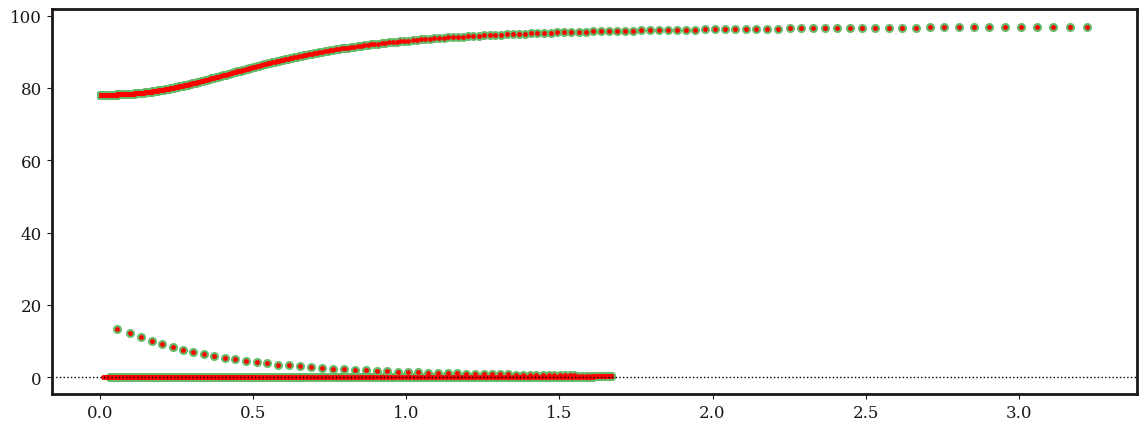

In [5]:
# Intialize the NNholo class: creates the NNs, imports the data, and sets the parameters for training

d = NNholo(data_path = sofT_list[0], contrastive_weights=None, nets_loc_var = 3, \
        saving_path = path_results, init_pt_curve=80, end_pt_curve=541, step=1, n_points=70, T_min=0.01, \
        add_index = True, solver_nets = [64,64,64], V_nets = [32,32,32,32],\
        V0_th_coef=1e-4, DV0_th_coef=1e-6, DDV0_th_coef=1e-6, 
        V_FV_th_coef=1e-6, DV_FV_th_coef=1e-6, DDV_FV_th_coef=1e-6,
        mono_phi_coef=0.0, steep_step=1, optimizer='Adam', load_optimizer=True, phim=phim_param[0])

#c.sofT_curve()

re_evol = [0.0]

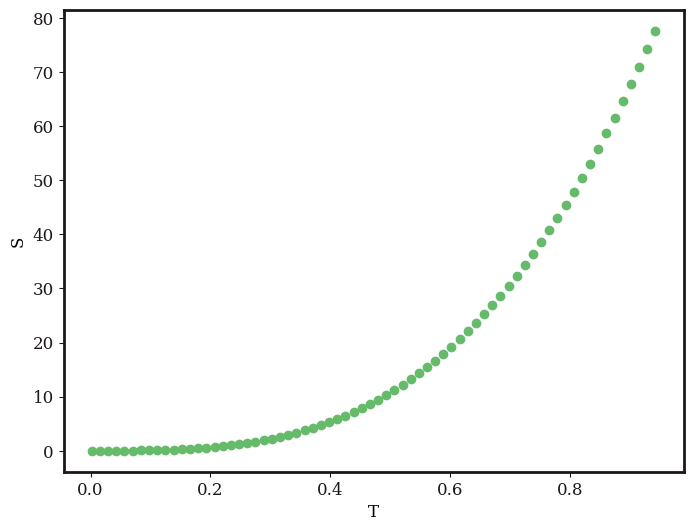

Last point: 0.0018385681 4.8594404e-07
Number of points: 70


In [6]:
# Visualize the training data points

S_pts = d.S_true.detach().numpy()
T_pts = d.T_true.detach().numpy()

plt.figure(figsize=(8,6))
plt.scatter(T_pts, S_pts)
plt.xlabel('T')
plt.ylabel('S')
plt.show()

print('Last point:', T_pts[-1], S_pts[-1])
print('Number of points:',len(T_pts))



In [7]:
# (Optional) Load pretrained results, for continuation of training or for visualization and inspection of the results

d.load_results(f'{path_results}/NN_first_branch_epochs_1961347')

Loaded optimizer state successfully.
Vth_min =  -3.47341161128519  at phi =  0.7023170231702317
DVth_min =  -1.364645263451936e-05
DDVth_min =  8.934198349997683
best nets not None
best nets not None
best nets not None
best nets not None
best nets not None
best nets not None
inside beg
Actual learning rate:  2.8970526256811803e-06
2.8970526256811803e-06
inside end
None
Model succesfully loaded


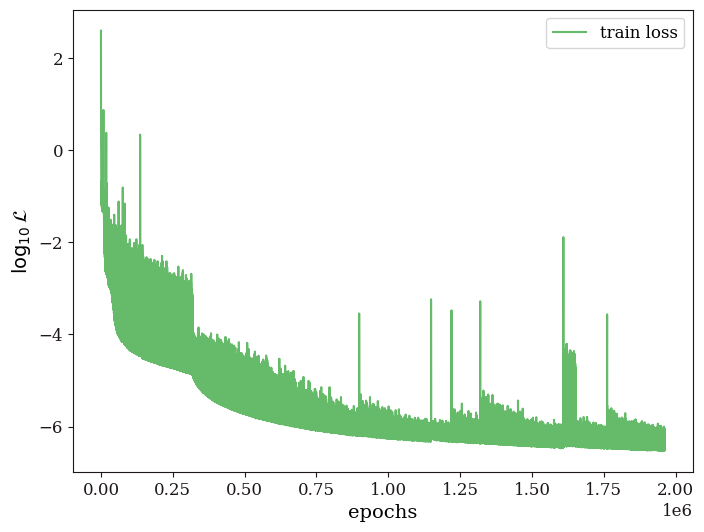

Min loss:  2.979712488960379e-07


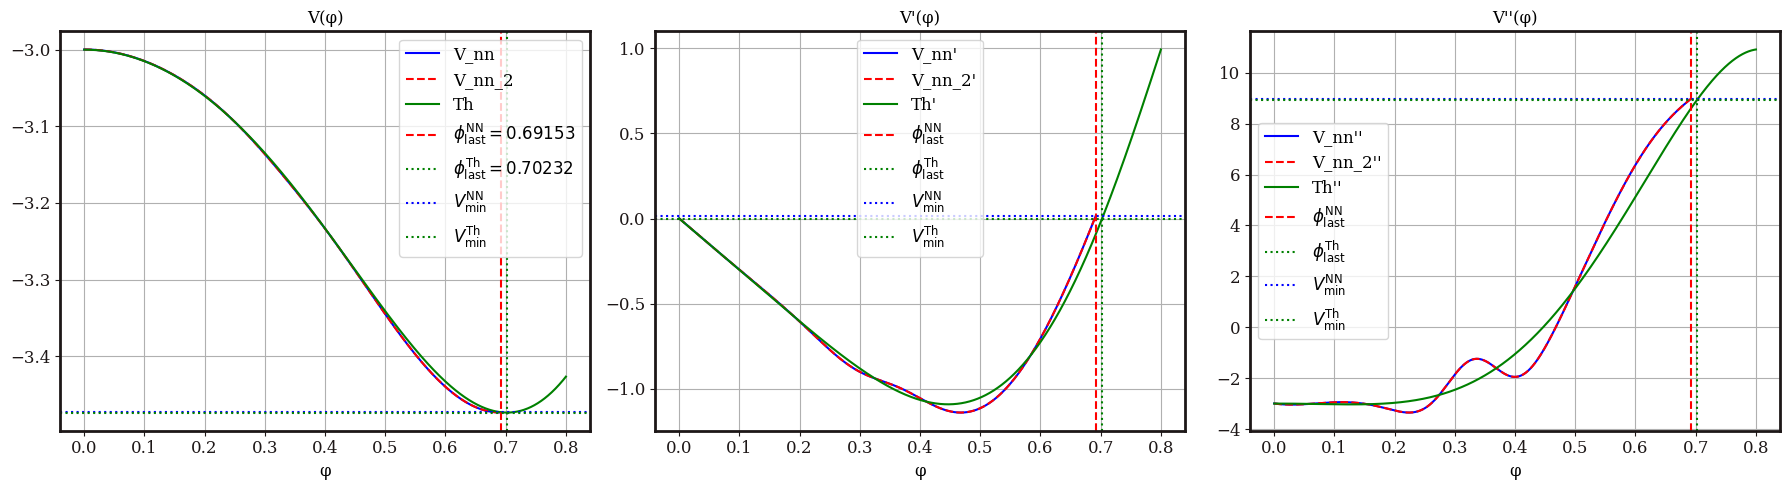

In [8]:
d.compute_current_V(save_fig=False)


## Train the model

In [9]:
# Instantiate the scheduler for the training

store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(d.optimizer, step_size=5000, gamma=0.98)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

param_tracker = TrackParameters()
#nets_param_tracker = TrackNetParameters()

In [10]:
# Check or update the lr of the optimizer

d.update_optimizer()
d.optimizer

inside beg
Actual learning rate:  2.8970526256811803e-06
2.8970526256811803e-06
inside end


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 2.8970526256811803e-06
    maximize: False
    weight_decay: 0
)

Epochs: 100%|██████████| 900/900 [00:54<00:00, 16.49iteration/s]


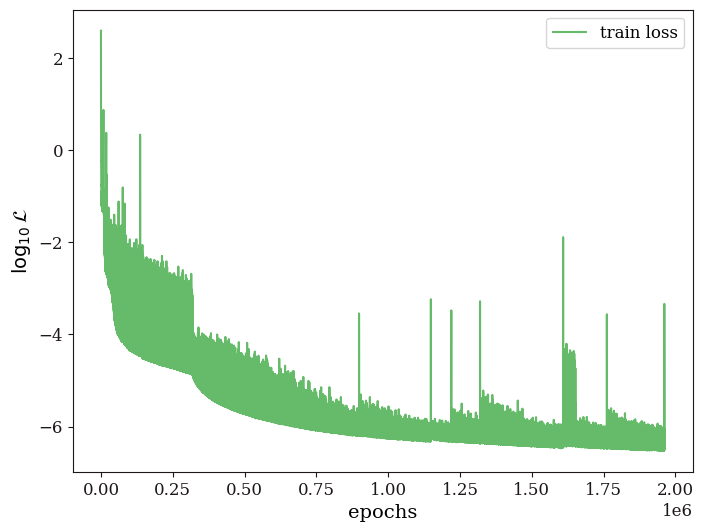

Min loss:  2.979712488960379e-07


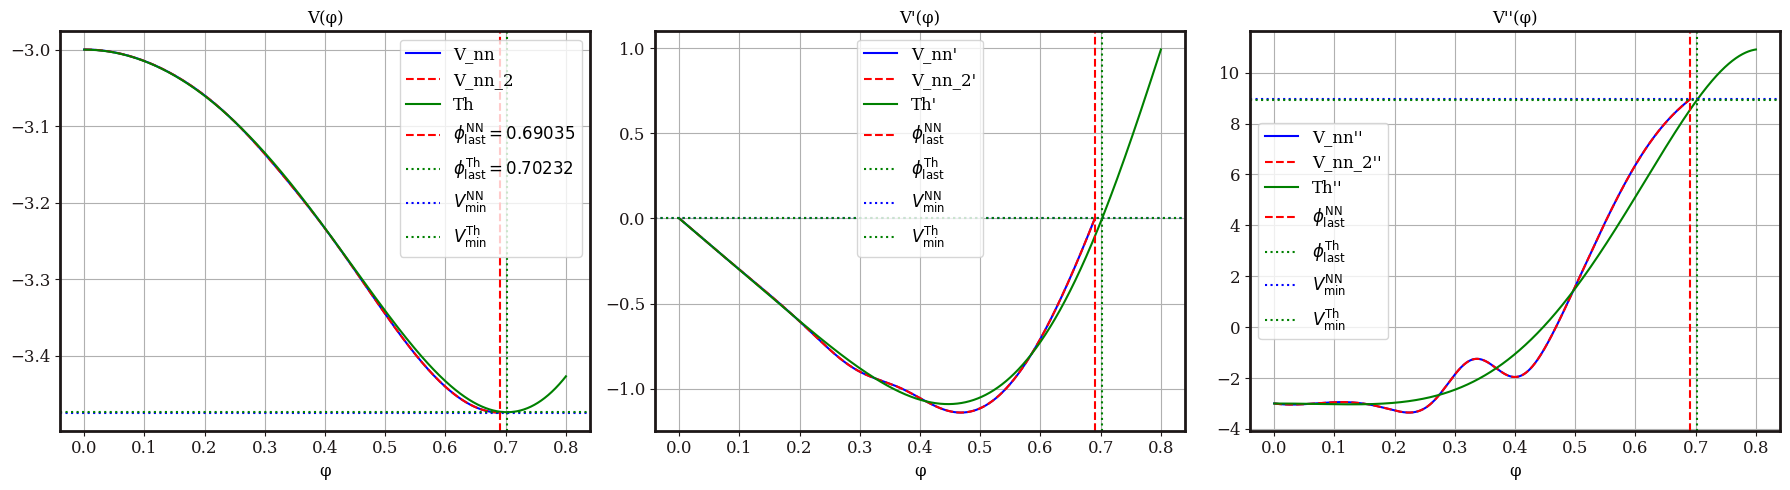

In [19]:

reps = 1
for epochs in range(reps):
    epochs = 900
    epochs = int(epochs)
    d.solver.fit(max_epochs=epochs, 
                callbacks=[potential_cb, scheduler_cb, param_tracker], #nets_param_tracker], 
                tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))
    
    
    d.compute_current_V(save_fig=True)
    
    # d.save_results(f'{path_results}/NN_first_branch')

#print(a-c.nets[0].Diss_net.NN[0].weight.detach().numpy())

In [36]:
# Save the current state of the model

d.save_results(f'{path_results}/NN_first_branch')

Model succesfully saved


## Visualize the loss function

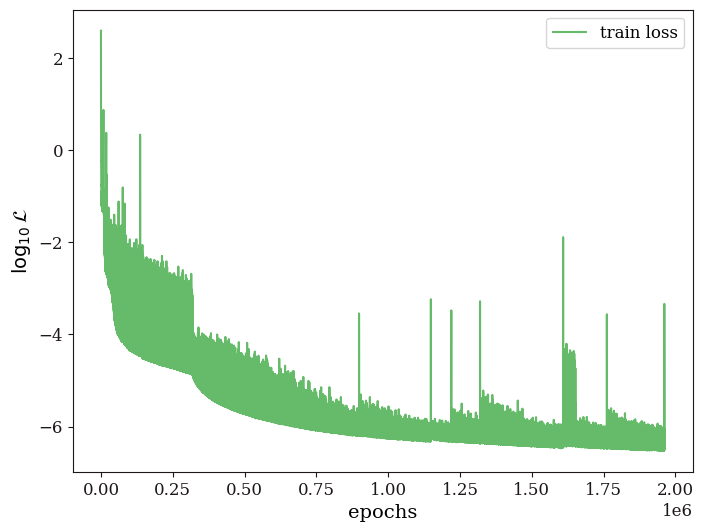

Min loss:  2.979712488960379e-07


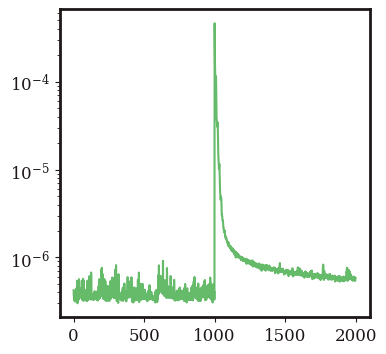

In [20]:
d.plot_loss()

past_epochs = 2000
train_loss = d.solver.metrics_history['train_loss']
plt.plot(train_loss[-past_epochs:], label='Train Loss')
plt.yscale('log')
plt.show()

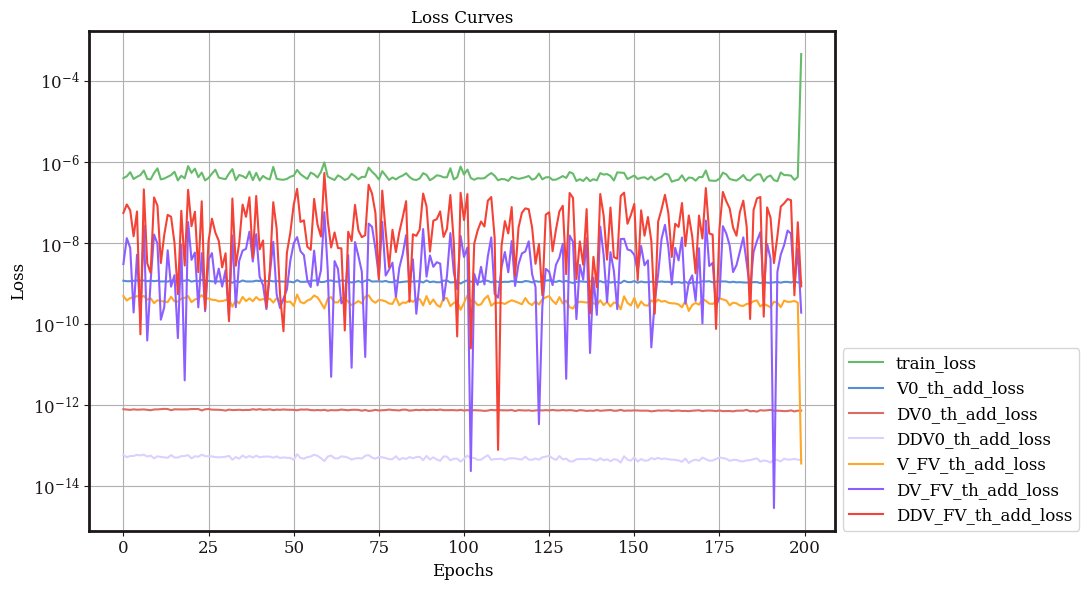

In [21]:
loss = d.solver.metrics_history

past_epochs = 200_000

step=1000

fig = plt.figure(figsize=(11, 6))

relevant_keys = ['train_loss', 'V0_th_add_loss', 'DV0_th_add_loss', 'DDV0_th_add_loss', 'V_FV_th_add_loss', 'DV_FV_th_add_loss', 'DDV_FV_th_add_loss']
for key in relevant_keys:
    plt.plot(loss[key][-past_epochs::step], label=key)

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc=(1.01,0))
plt.title('Loss Curves')
plt.grid()
plt.tight_layout()
plt.show()

## Results

### Analyze the recovered potential $V(\phi)$

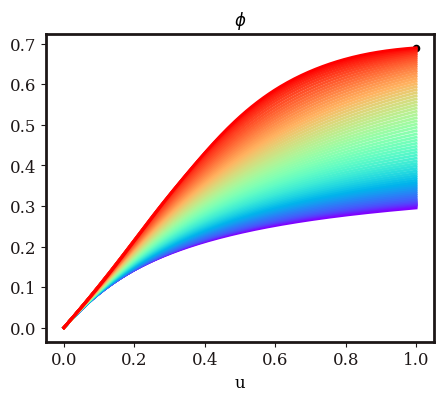

In [22]:
u = torch.linspace(0,1,250)
var_names = ['Vs', 'Va', 'Vp', r'$\Sigma$', 'A', r'$\phi$']

fig= plt.figure(figsize=(5,4))

step = 1

RES = []
phi_solutions = []
step = step

j = 5  # phi solution
for i in range(len(d.Va_uh_all)):
    S = d.Sigma_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    T = d.Va_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    Z = d.Z[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    #print(c.solver.get_residuals(u,S,T))
    #res = c.solver.get_residuals(u,S,T,Z,best= False)
    sol = d.solver.get_solution(best = True)
    phi_sol = sol(u,S,T,Z)[j]
    #  RES.append(torch.stack(res).mean(dim = 0))
    phi_solutions.append(phi_sol.cpu().detach().numpy())

phi_last = phi_solutions[-1][-1]

for i in range(len(d.Va_uh_all)):
    S = d.Sigma_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    T = d.Va_uh_all[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    Z = d.Z[i].cpu().detach().numpy()*np.ones_like(u.cpu().detach().numpy())
    #print(c.solver.get_residuals(u,S,T))
    #res = c.solver.get_residuals(u,S,T,Z,best= False)
    sol = d.solver.get_solution(best = True)
    phi_sol = sol(u,S,T,Z)[j]
    #  RES.append(torch.stack(res).mean(dim = 0))
    phi_solutions.append(phi_sol.cpu().detach().numpy())

phi_last_2 = phi_solutions[-1][-1]

num_curves = len(d.Va_uh_all)
cmap = cm.get_cmap('rainbow', num_curves)
norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

for i in range(num_curves):
    #if i == step:# == 0:
    if i % step == 0:

        col = cmap(i / (num_curves - 1))
        
        y = u.cpu().detach().numpy()
        z = phi_solutions[i]

        plt.plot(y, z, color=col, linewidth=2, label=i)
        plt.title(var_names[j])
plt.scatter(1.0, phi_last, c = 'k', s=20)
plt.xlabel('u')
# plt.legend(loc=(1.1,0.3))
plt.show()

In [23]:
phi_mock = np.linspace(-0.1,1.0,1000)
p = torch.linspace(0,1.0,1000, requires_grad=True).reshape(-1,1)
Vth = V_or(phi_mock, phim=phim_param[0])
Vnn = d.solver.V(p)

N = 3
derivatives = [Vth]
derivatives_nn = [Vnn]
deriv_min = []
deriv_min_nn = []
for i in range(N):
    if i==0:
        Vmin = min(Vth)
        Vmin_nn = torch.min(Vnn)
        idx = np.argmin(Vth)
        idx_nn = torch.argmin(Vnn)
        deriv_min.append(Vmin)
        deriv_min_nn.append(Vmin_nn.cpu().detach().numpy())
    else:

        val = np.gradient(derivatives[-1], phi_mock)
        val_nn = diff(derivatives_nn[-1], p, order=1)
        derivatives.append(val)
        derivatives_nn.append(val_nn)
        deriv_min.append(val[idx])
        deriv_min_nn.append(val_nn[idx_nn].cpu().detach().numpy())

print('V_nn(0)', derivatives_nn[0][0].cpu().detach().numpy())
print('DV_nn(0)', derivatives_nn[1][0].cpu().detach().numpy())
print('DDV_nn(0)', derivatives_nn[2][0].cpu().detach().numpy())



V_nn(0) [-2.999817]
DV_nn(0) [0.00085385]
DDV_nn(0) [-2.9979086]


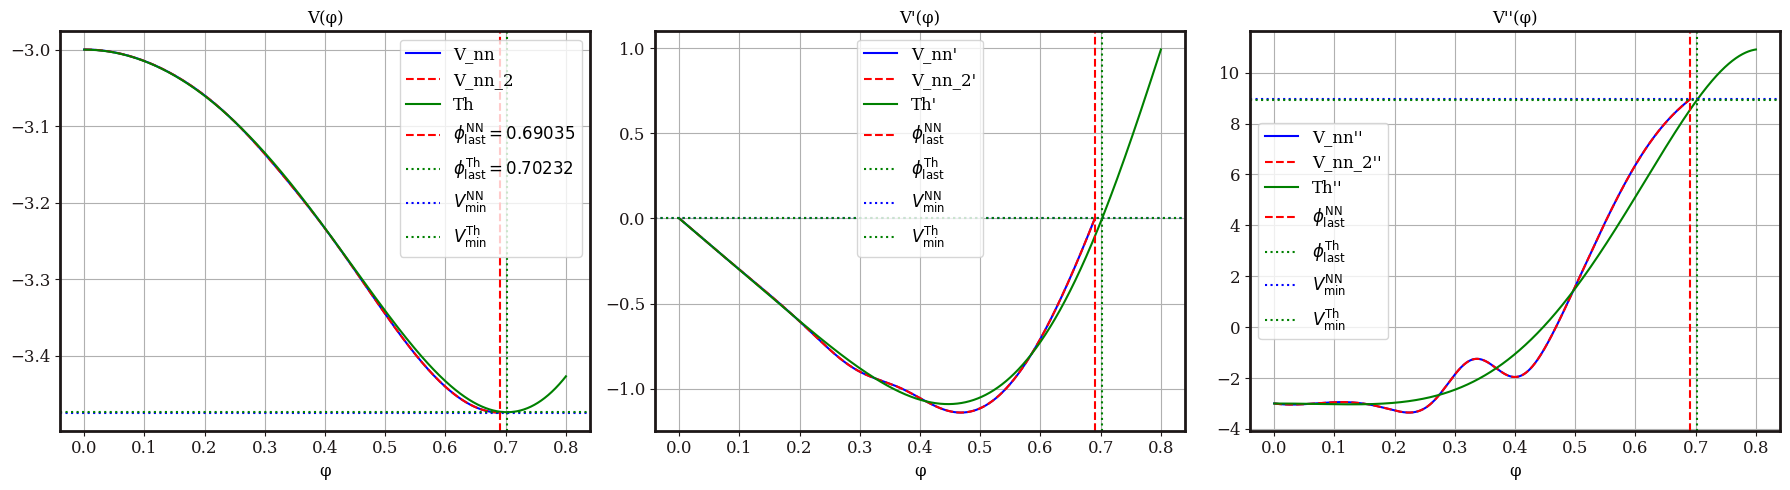

V(0): NN= -2.99981689453125  , NN_2= -2.99981689453125  , Th = -3.0  , diff= 0.00018310546875
---------------------------------------
DV(0): NN= 0.0008538513211533427  , NN_2= 0.0008538513211533427  , Th = -0.0  , diff= 0.0008538513211533427
---------------------------------------
DDV(0): NN= -2.997908592224121  , NN_2= -2.997908592224121  , Th = -3.0  , diff= 0.0020914077758789062
V(min): NN= -3.4738898277282715  , NN_2= -3.4738898277282715  , Th = -3.473411611294614  , diff= -0.0004782676696777344
---------------------------------------
DV(min) NN= 0.0009223687811754644  , NN_2= 0.0009223687811754644  , Th = 4.222187680031511e-06  , diff= 0.0009181465720757842
---------------------------------------
DDV(min) NN= 8.948892593383789  , NN_2= 8.948892593383789  , Th = 8.93426327656315  , diff= 0.014629364013671875


In [24]:
phi = torch.linspace(0.0, phi_last, 10000, requires_grad=True).reshape(-1,1)
V_nn = d.solver.V(phi)
V_nn_2 = d.solver.V(phi)

DV_nn = diff(V_nn.reshape(-1, 1), phi, order=1)
DDV_nn = diff(V_nn.reshape(-1, 1), phi, order=2)

DV_nn_np = DV_nn.detach().numpy().reshape(-1,)
DDV_nn_np = DDV_nn.detach().numpy().reshape(-1,)

DV_nn_2 = diff(V_nn_2.reshape(-1, 1), phi, order=1)
DDV_nn_2 = diff(V_nn_2.reshape(-1, 1), phi, order=2)

DV_nn_2_np = DV_nn_2.detach().numpy().reshape(-1,)
DDV_nn_2_np = DDV_nn_2.detach().numpy().reshape(-1,)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

phi_np = phi.detach().numpy().reshape(-1,)
Vnn_np = V_nn.detach().numpy().reshape(-1,)
Vnn_2_np = V_nn_2.detach().numpy().reshape(-1,)




phi_th = np.linspace(0,0.8,100000)

V_th = V_or(phi_th, phim=0.55)
DV_th = DV_or(phi_th, phim=0.55)
DDV_th = DDV_or(phi_th, phim=0.55)

Vmin_th = min(V_th)
phi_FV_th = phi_th[np.argmin(V_th)]
DVmin_th = DV_th[np.argmin(V_th)]
DDVmin_th = DDV_th[np.argmin(V_th)]


# --- 1) Potential ---
axes[0].plot(phi_np, Vnn_np, label='V_nn', color='blue')
axes[0].plot(phi_np, Vnn_2_np, label='V_nn_2', color='red', linestyle='dashed')
axes[0].plot(phi_th, V_th, label='Th', color='green')
axes[0].axvline(phi_last, color='red', linestyle='dashed', label=rf'$\phi_\text{{last}}^\text{{NN}} = {phi_last:.5f}$')
axes[0].axvline(phi_th[np.argmin(V_th)], color='green', linestyle='dotted', label=rf'$\phi_\text{{last}}^\text{{Th}} = {phi_th[np.argmin(V_th)]:.5f}$')
axes[0].axhline(V_nn[-1].detach().numpy(), color='blue', linestyle='dotted', label=r'$V_\text{min}^\text{NN}$')
axes[0].axhline(Vmin_th, color='green', linestyle='dotted', label=rf'$V_\text{{min}}^\text{{Th}}$')

axes[0].set_title('V(φ)')
axes[0].legend()
axes[0].grid()

# --- 2) First derivative ---
axes[1].plot(phi_np, DV_nn_np, label="V_nn'", color='blue')
axes[1].plot(phi_np, DV_nn_2_np, label="V_nn_2'", color='red', linestyle='dashed')
axes[1].plot(phi_th, DV_th, label="Th'", color='green')
axes[1].axvline(phi_last, color='red', linestyle='dashed', label=r'$\phi_\text{last}^\text{NN}$')
axes[1].axvline(phi_th[np.argmin(V_th)], color='green', linestyle='dotted', label=r'$\phi_\text{last}^\text{Th}$')
axes[1].axhline(DV_nn[-1].detach().numpy(), color='blue', linestyle='dotted', label=r'$V_\text{min}^\text{NN}$')
axes[1].axhline(DVmin_th, color='green', linestyle='dotted', label=r'$V_\text{min}^\text{Th}$')
axes[1].set_title("V'(φ)")
axes[1].legend()
axes[1].grid()

# --- 3) Second derivative ---
axes[2].plot(phi_np, DDV_nn_np, label="V_nn''", color='blue')
axes[2].plot(phi_np, DDV_nn_2_np, label="V_nn_2''", color='red', linestyle='dashed')
axes[2].plot(phi_th, DDV_th, label="Th''", color='green')
axes[2].axvline(phi_last, color='red', linestyle='dashed', label=r'$\phi_\text{last}^\text{NN}$')
axes[2].axvline(phi_th[np.argmin(V_th)], color='green', linestyle='dotted', label=r'$\phi_\text{last}^\text{Th}$')
axes[2].axhline(DDV_nn[-1].detach().numpy(), color='blue', linestyle='dotted', label=r'$V_\text{min}^\text{NN}$')
axes[2].axhline(DDVmin_th, color='green', linestyle='dotted', label=r'$V_\text{min}^\text{Th}$')
axes[2].set_title("V''(φ)")
axes[2].legend()
axes[2].grid()

for ax in axes:
    ax.set_xlabel('φ')

plt.tight_layout()
plt.show()

print(
    'V(0): NN=', float(V_nn[0].detach().numpy()),
    ' , NN_2=', float(V_nn_2[0]),
    ' , Th =', float(V_th[0]),
    ' , diff=', float(V_nn_2[0] - V_th[0])
)

print('---------------------------------------')

print(
    'DV(0): NN=', float(DV_nn[0]),
    ' , NN_2=', float(DV_nn_2[0]),
    ' , Th =', float(DV_th[0]),
    ' , diff=', float(DV_nn_2[0] - DV_th[0])
)

print('---------------------------------------')

print(
    'DDV(0): NN=', float(DDV_nn[0]),
    ' , NN_2=', float(DDV_nn_2[0]),
    ' , Th =', float(DDV_th[0]),
    ' , diff=', float(DDV_nn_2[0] - DDV_th[0])
)

print('=======================================')
print('=======================================')

print(
    r'V(min): NN=', float(V_nn[-1].detach().numpy()),
    ' , NN_2=', float(V_nn_2[-1]),
    ' , Th =', float(Vmin_th),
    ' , diff=', float(V_nn_2[-1] - Vmin_th)
)

print('---------------------------------------')

print(
    r'DV(min) NN=', float(DV_nn[-1]),
    ' , NN_2=', float(DV_nn_2[-1]),
    ' , Th =', float(DVmin_th),
    ' , diff=', float(DV_nn_2[-1] - DVmin_th)
)

print('---------------------------------------')

print(
    r'DDV(min) NN=', float(DDV_nn[-1]),
    ' , NN_2=', float(DDV_nn_2[-1]),
    ' , Th =', float(DDVmin_th),
    ' , diff=', float(DDV_nn_2[-1] - DDVmin_th)
)

# fig.savefig(f'{d.path}/V_DV_DDV_nn_vs_th_epochs_{d.solver.global_epoch}.png', dpi=300)


### Visualize the solutions and residuals

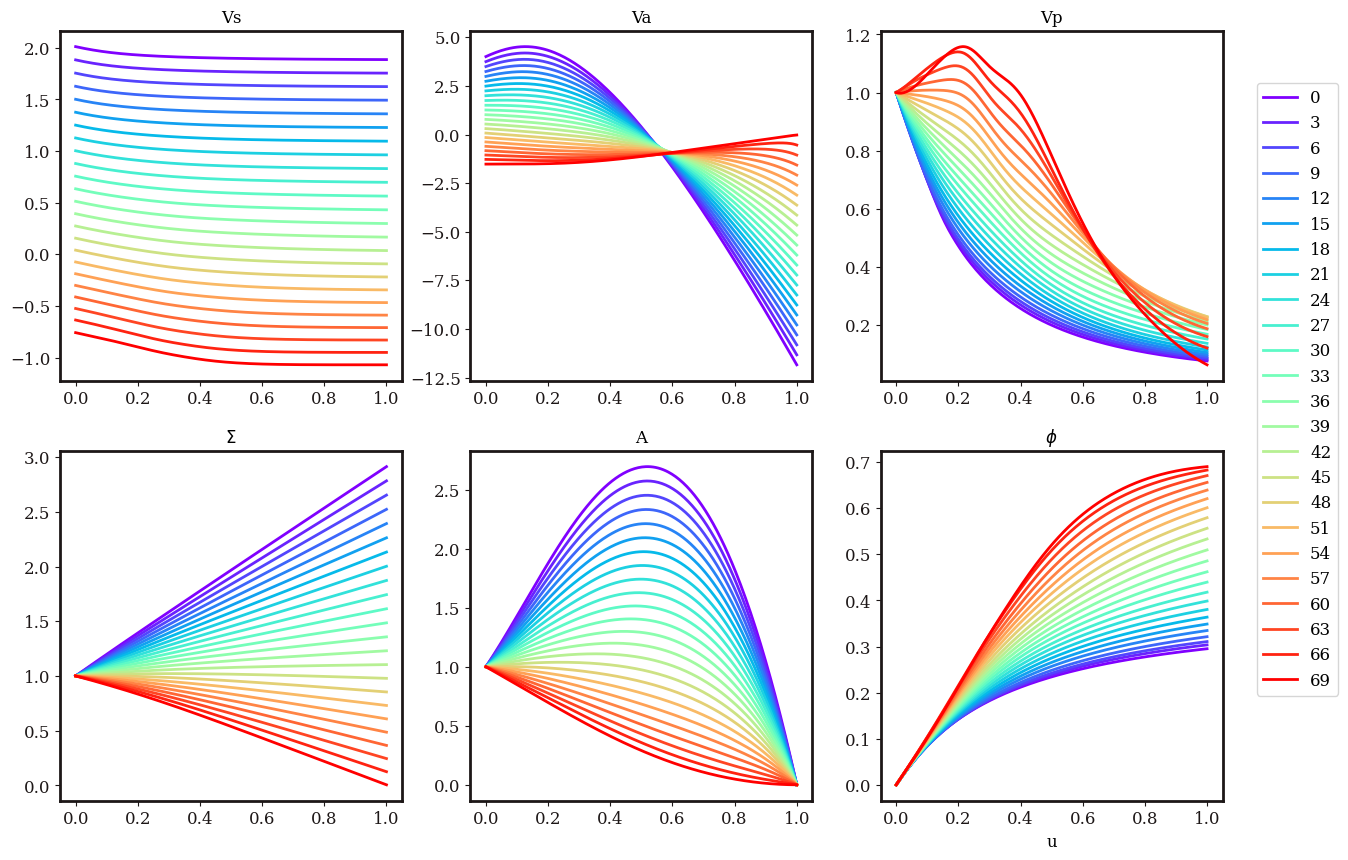

In [25]:
d.plot_solutions(step=3, save_fig=True)

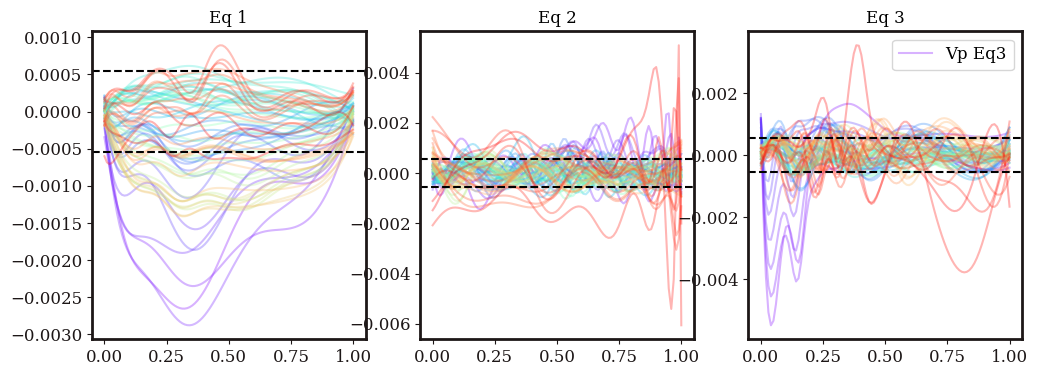

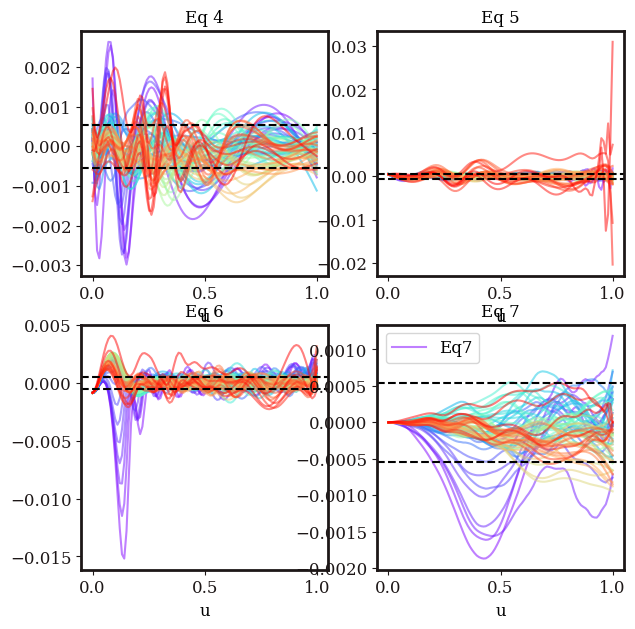

In [33]:
d.plot_residuals_in_u_color(save_fig=True)

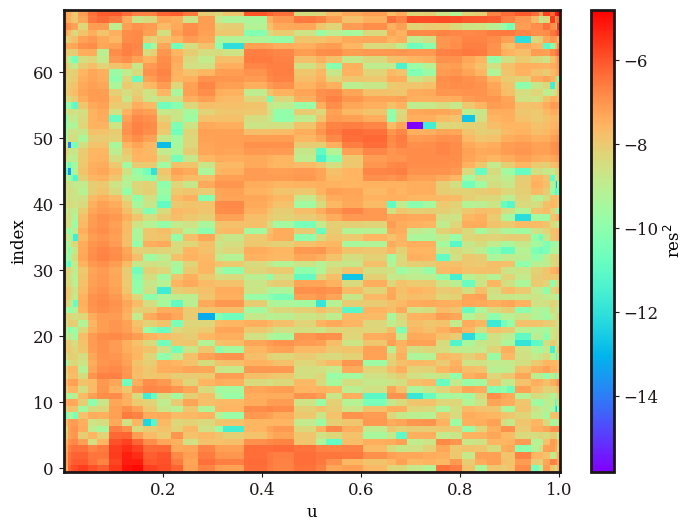

In [ ]:
d.plot_2D_residuals()

### Metric for accuracy of $V(\phi)$:

We take:
$$ RE=\int_0^{\phi_H^\textup{th}} \frac{|V^\textup{th}(\phi) - V^\textup{NN}(\phi)|}{|V^\textup{th}(\phi)|} \textup{d}\phi + \int_{\phi_H^\textup{th}}^{\phi_H^\textup{NN}} \frac{|V^\textup{th}(\phi_H^\textup{th}) - V^\textup{NN}(\phi)|}{|V^\textup{th}(\phi_H^\textup{th})|} \textup{d}\phi$$

RE 0.0006305459911118584


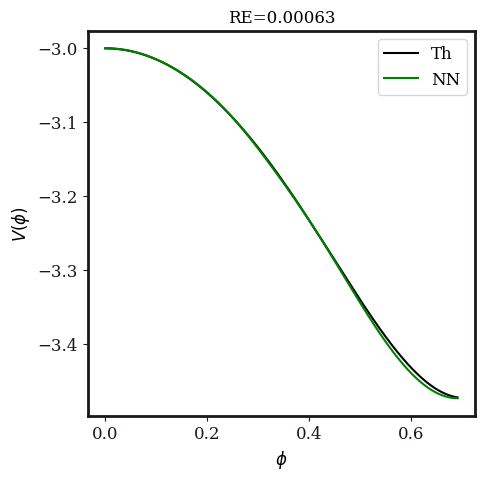

In [31]:
d.compute_relative_error(save_fig=True, phim_param=0.55)

### Solution 3D plots

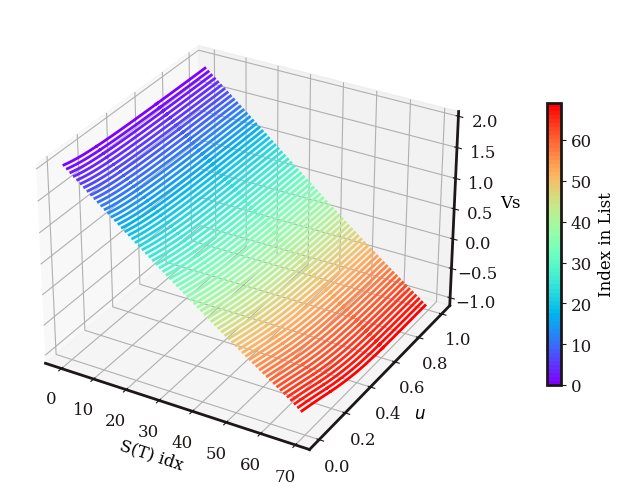

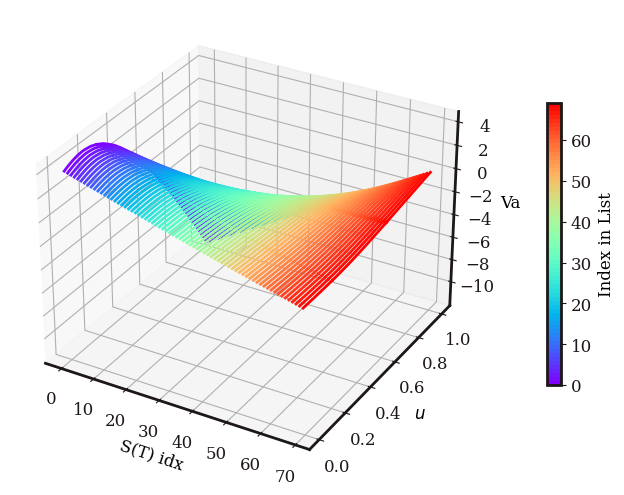

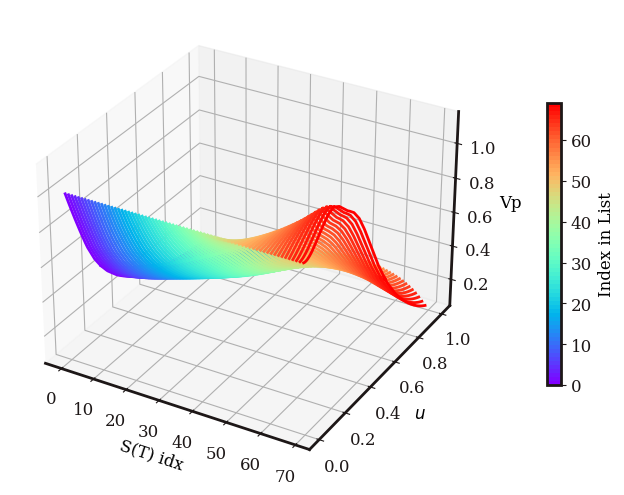

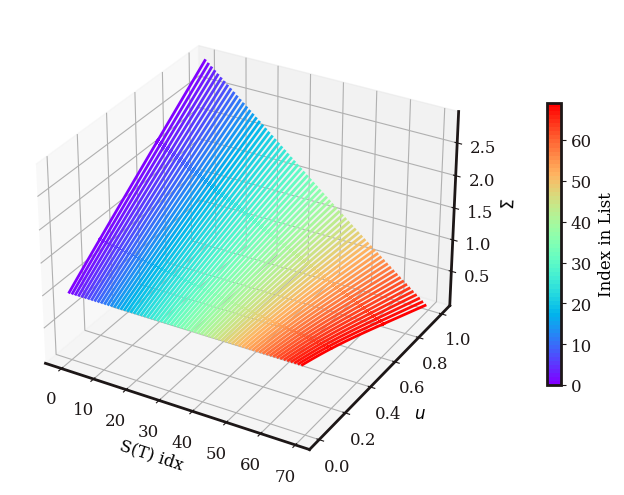

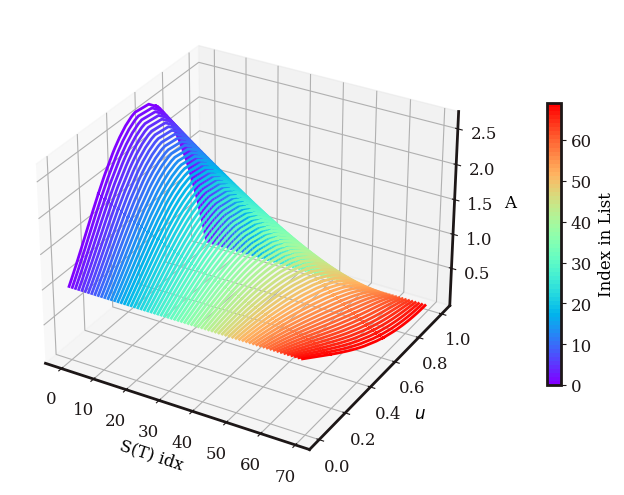

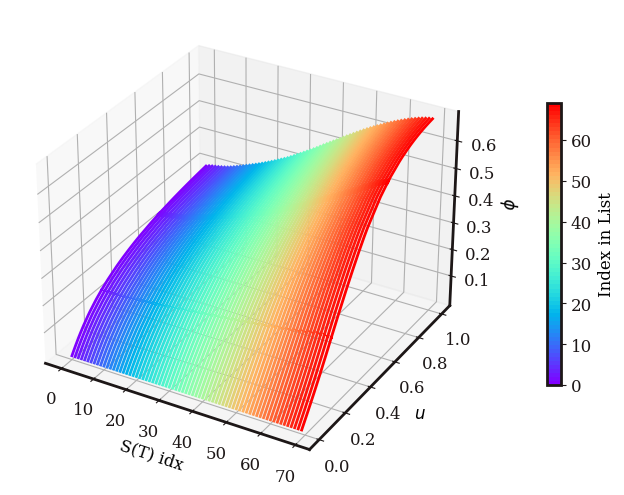

In [32]:
u = c.g1.get_examples()

var_names = ['Vs', 'Va', 'Vp', r'$\Sigma$', 'A', r'$\phi$']

for j in range(6):
    RES = []
    phi_solutions = []
    step = 1
    for i in range(len(c.Va_uh_all)):
        S = c.Sigma_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
        T = c.Va_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
        Z = c.Z[i].detach().numpy()*np.ones_like(u.detach().numpy())
        #print(c.solver.get_residuals(u,S,T))
        #res = c.solver.get_residuals(u,S,T,Z,best= False)
        sol = c.solver.get_solution(best = True)
        phi_sol = sol(u,S,T,Z)[j]
      #  RES.append(torch.stack(res).mean(dim = 0))
        phi_solutions.append(phi_sol.detach().numpy())
    
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    num_curves = len(c.Va_uh_all)
    cmap = cm.get_cmap('rainbow', num_curves)
    norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    for i in range(num_curves):
        if i % step == 0:
            col = cmap(i / (num_curves - 1))
            
            y = u.detach().numpy()
            z = phi_solutions[i]
            x = np.full_like(y, i)  # Constant z value per curve (index i)
    
            ax.plot(x, y, z, color=col, linewidth=2)
    
    # Add colorbar
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad = 0.1)
    cbar.set_label("Index in List")
    
    ax.set_xlabel('S(T) idx')
    ax.set_ylabel(r'$u$')
    ax.set_zlabel(var_names[j])

    plt.tight_layout()
    plt.show()


### Analyze solutions independently

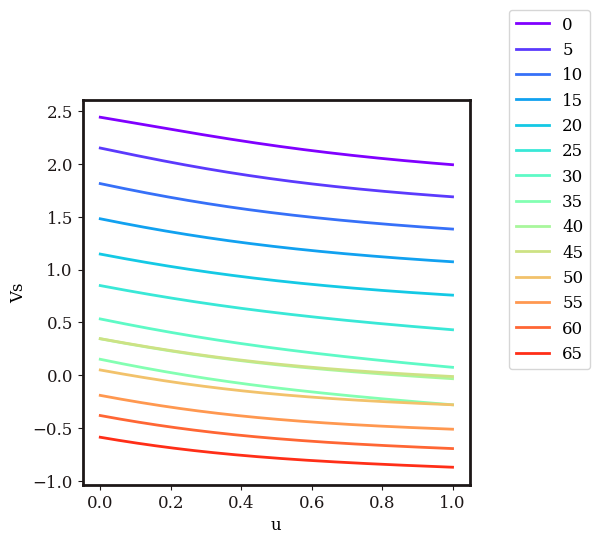

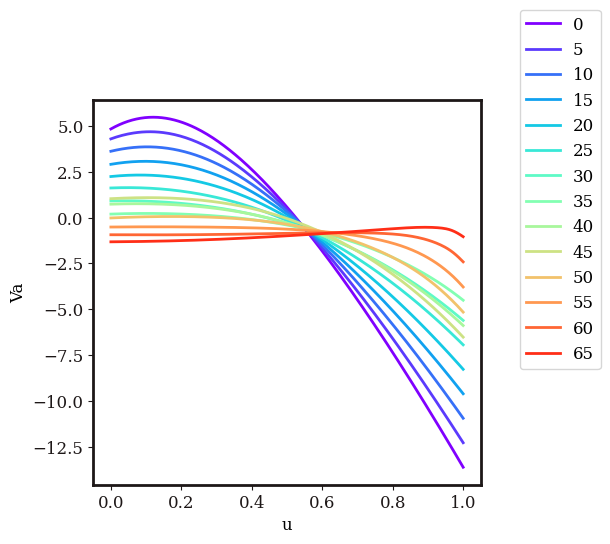

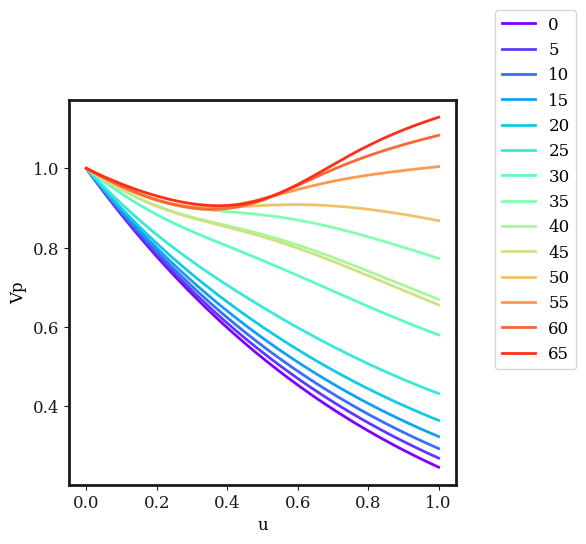

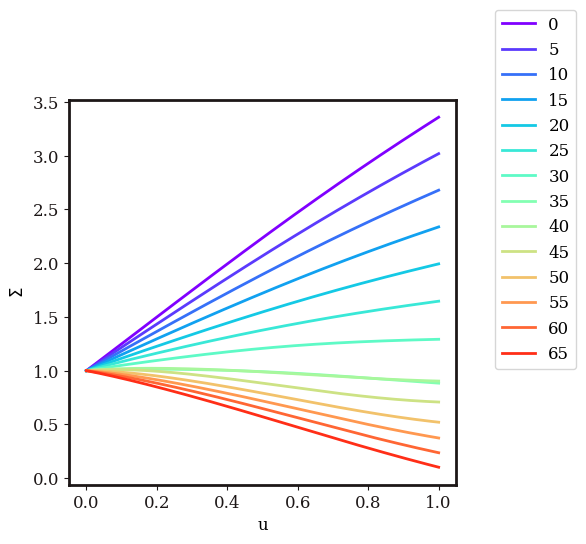

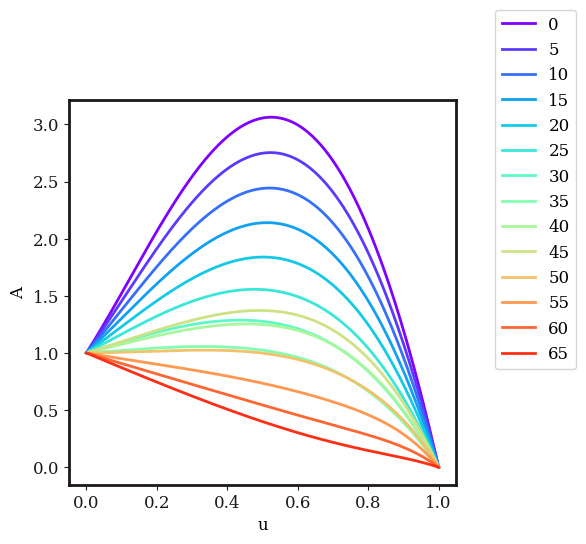

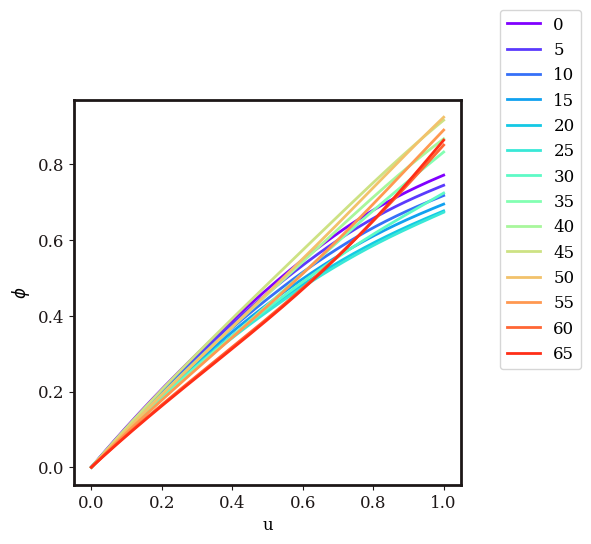

In [ ]:
u = torch.linspace(0,1,250)

var_names = ['Vs', 'Va', 'Vp', r'$\Sigma$', 'A', r'$\phi$']

for j in range(6):
    RES = []
    phi_solutions = []
    step = 5
    for i in range(len(c.Va_uh_all)):
        S = c.Sigma_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
        T = c.Va_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
        Z = c.Z[i].detach().numpy()*np.ones_like(u.detach().numpy())
        #print(c.solver.get_residuals(u,S,T))
        #res = c.solver.get_residuals(u,S,T,Z,best= False)
        sol = c.solver.get_solution(best = True)
        phi_sol = sol(u,S,T,Z)[j]
      #  RES.append(torch.stack(res).mean(dim = 0))
        phi_solutions.append(phi_sol.detach().numpy())
    
    fig = plt.figure(figsize=(5, 5))
    num_curves = len(c.Va_uh_all)
    cmap = cm.get_cmap('rainbow', num_curves)
    norm = mcolors.Normalize(vmin=0, vmax=num_curves - 1)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    for i in range(num_curves):
        #if i == step:# == 0:
        if i % step == 0:

            col = cmap(i / (num_curves - 1))
            
            y = u.detach().numpy()
            z = phi_solutions[i]
           # x = np.full_like(y, i)  # Constant z value per curve (index i)
    
            plt.plot(y, z, color=col, linewidth=2, label=i)
    #plt.colorbar(sm, ax=ax, shrink=0.6, pad = 0.1)
    plt.xlabel('u')
    plt.ylabel(var_names[j])
    plt.legend(loc=(1.1,0.3))
#    ax.set_zlabel(var_names[j])
    plt.show()